# Artificial Grid Torus Check (PCA -> UMAP)

This notebook uses a clean synthetic baseline:
1. Generate perfect hexagonal grid cells (fixed scale).
2. Build population matrix `X` with samples = positions, features = cells.
3. Run `PCA(6) -> UMAP(3)` and compare with known torus coordinates.

Torch-based methods are intentionally removed.

In [17]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_THREADING_LAYER", "SEQUENTIAL")

_tmp_base = Path("..") / ".tmp_numba"
_tmp_base.mkdir(parents=True, exist_ok=True)
(_tmp_base / "numba_cache").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("TMP", str(_tmp_base.resolve()))
os.environ.setdefault("TEMP", str(_tmp_base.resolve()))
os.environ.setdefault("NUMBA_CACHE_DIR", str((_tmp_base / "numba_cache").resolve()))

try:
    import umap
except Exception as e:
    raise RuntimeError("umap-learn is required for this notebook.") from e


c:\Users\User\miniconda3\envs\dlenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
def make_hex_reciprocal_vectors(scale, orientation=0.0):
    k = 2.0 * np.pi / scale
    th = np.deg2rad(float(orientation))
    k1 = k * np.array([np.cos(th), np.sin(th)], dtype=np.float32)
    k2 = k * np.array([np.cos(th + np.pi / 3.0), np.sin(th + np.pi / 3.0)], dtype=np.float32)
    k3 = k1 - k2
    return k1, k2, k3


def make_position_grid(box_width=3.0, box_height=3.0, res_x=70, res_y=70):
    xs = np.linspace(-box_width / 2.0, box_width / 2.0, res_x, dtype=np.float32)
    ys = np.linspace(-box_height / 2.0, box_height / 2.0, res_y, dtype=np.float32)
    xx, yy = np.meshgrid(xs, ys)
    pos = np.stack([xx.reshape(-1), yy.reshape(-1)], axis=1)
    return pos, xx, yy


def make_perfect_grid_population(pos, n_cells=128, scale=1.0, orientation=0.0, beta=2.5, seed=0):
    rng = np.random.default_rng(seed)
    k1, k2, k3 = make_hex_reciprocal_vectors(scale=scale, orientation=orientation)

    phi1 = rng.uniform(0.0, 2.0 * np.pi, size=n_cells).astype(np.float32)
    phi2 = rng.uniform(0.0, 2.0 * np.pi, size=n_cells).astype(np.float32)
    phi3 = phi1 - phi2

    proj1 = pos @ k1
    proj2 = pos @ k2
    proj3 = pos @ k3

    activity = np.exp(
        beta
        * (
            np.cos(proj1[:, None] + phi1[None, :])
            + np.cos(proj2[:, None] + phi2[None, :])
            + np.cos(proj3[:, None] + phi3[None, :])
        )
        / 3.0
    ).astype(np.float32)
    return activity


def true_torus_coordinates(pos, scale=1.0, orientation=0.0, R=2.0, r=0.75):
    k1, k2, _ = make_hex_reciprocal_vectors(scale=scale, orientation=orientation)
    u = np.mod(pos @ k1, 2.0 * np.pi)
    v = np.mod(pos @ k2, 2.0 * np.pi)
    x = (R + r * np.cos(v)) * np.cos(u)
    y = (R + r * np.cos(v)) * np.sin(u)
    z = r * np.sin(v)
    return np.stack([x, y, z], axis=1).astype(np.float32), u.astype(np.float32), v.astype(np.float32)


def zscore_columns(X):
    mean = X.mean(axis=0, keepdims=True)
    std = X.std(axis=0, keepdims=True) + 1e-8
    return (X - mean) / std


def reduce_pca_umap(X, n_pca=6, n_umap=3, n_neighbors=30, min_dist=0.1, random_state=0):
    Xz = zscore_columns(np.asarray(X, dtype=np.float32)).astype(np.float32)

    pca = PCA(n_components=int(n_pca), svd_solver="full", random_state=int(random_state))
    X_pca = pca.fit_transform(Xz).astype(np.float32)

    reducer = umap.UMAP(
        n_components=int(n_umap),
        n_neighbors=int(n_neighbors),
        min_dist=float(min_dist),
        metric="euclidean",
        random_state=int(random_state),
        n_jobs=1,
        low_memory=True,
        transform_seed=int(random_state),
    )
    X_umap = reducer.fit_transform(X_pca).astype(np.float32)
    return X_pca, X_umap, pca


In [25]:
# Synthetic setup
box_width = 3.0
box_height = 3.0
res_x = 100
res_y = 100
n_cells = 128
scale = 1.0
orientation = 0.0
beta = 2.5
seed = 0
max_samples = 10000

pos, xx, yy = make_position_grid(box_width=box_width, box_height=box_height, res_x=res_x, res_y=res_y)
X = make_perfect_grid_population(pos, n_cells=n_cells, scale=scale, orientation=orientation, beta=beta, seed=seed)
torus_xyz, phase_u, phase_v = true_torus_coordinates(pos, scale=scale, orientation=orientation)

print("Population matrix:", X.shape)
print("Position samples:", pos.shape)


Population matrix: (10000, 128)
Position samples: (10000, 2)


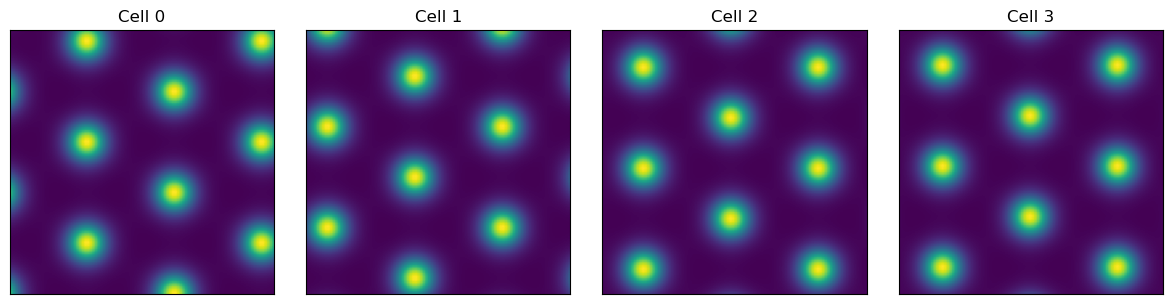

In [26]:
# Visualize a few synthetic perfect grid cells
show_ids = [0, 1, 2, 3]
fig, axes = plt.subplots(1, len(show_ids), figsize=(3 * len(show_ids), 3))
for ax, cid in zip(axes, show_ids):
    rm = X[:, cid].reshape(res_y, res_x)
    ax.imshow(rm, origin="lower", cmap="viridis", extent=[-box_width/2, box_width/2, -box_height/2, box_height/2])
    ax.set_title(f"Cell {cid}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()


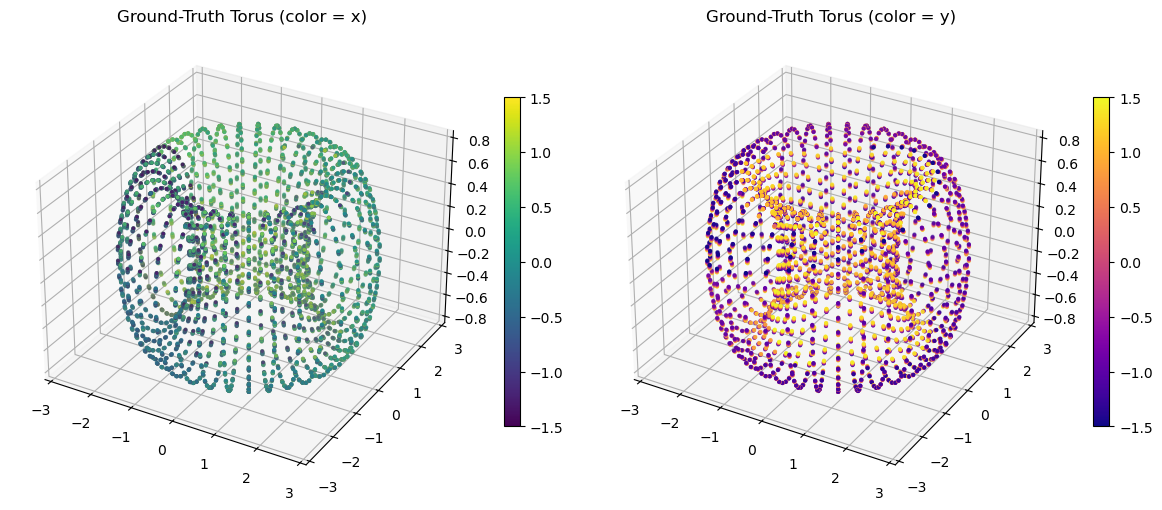

In [27]:
# Ground-truth torus coordinates from latent phases
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection="3d")
p1 = ax1.scatter(torus_xyz[:, 0], torus_xyz[:, 1], torus_xyz[:, 2], c=pos[:, 0], s=4, cmap="viridis")
ax1.set_title("Ground-Truth Torus (color = x)")
fig.colorbar(p1, ax=ax1, shrink=0.7)

ax2 = fig.add_subplot(122, projection="3d")
p2 = ax2.scatter(torus_xyz[:, 0], torus_xyz[:, 1], torus_xyz[:, 2], c=pos[:, 1], s=4, cmap="plasma")
ax2.set_title("Ground-Truth Torus (color = y)")
fig.colorbar(p2, ax=ax2, shrink=0.7)
plt.tight_layout()
plt.show()


In [28]:
# PCA -> UMAP on synthetic population states
if X.shape[0] > max_samples:
    rng = np.random.default_rng(seed)
    keep_idx = np.sort(rng.choice(X.shape[0], size=max_samples, replace=False))
else:
    keep_idx = np.arange(X.shape[0])

X_sub = X[keep_idx]
pos_sub = pos[keep_idx]
torus_sub = torus_xyz[keep_idx]
u_sub = phase_u[keep_idx]
v_sub = phase_v[keep_idx]

X_pca, X_umap, pca = reduce_pca_umap(
    X_sub,
    n_pca=6,
    n_umap=3,
    n_neighbors=30,
    min_dist=0.1,
    random_state=seed,
)

print("Subsampled matrix:", X_sub.shape)
print("PCA output:", X_pca.shape)
print("UMAP output:", X_umap.shape)
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print("Cumulative:", np.round(np.cumsum(pca.explained_variance_ratio_), 4))


Subsampled matrix: (10000, 128)
PCA output: (10000, 6)
UMAP output: (10000, 3)
Explained variance ratio: [0.1862 0.1496 0.1382 0.1241 0.116  0.1113]
Cumulative: [0.1862 0.3358 0.474  0.5982 0.7141 0.8254]


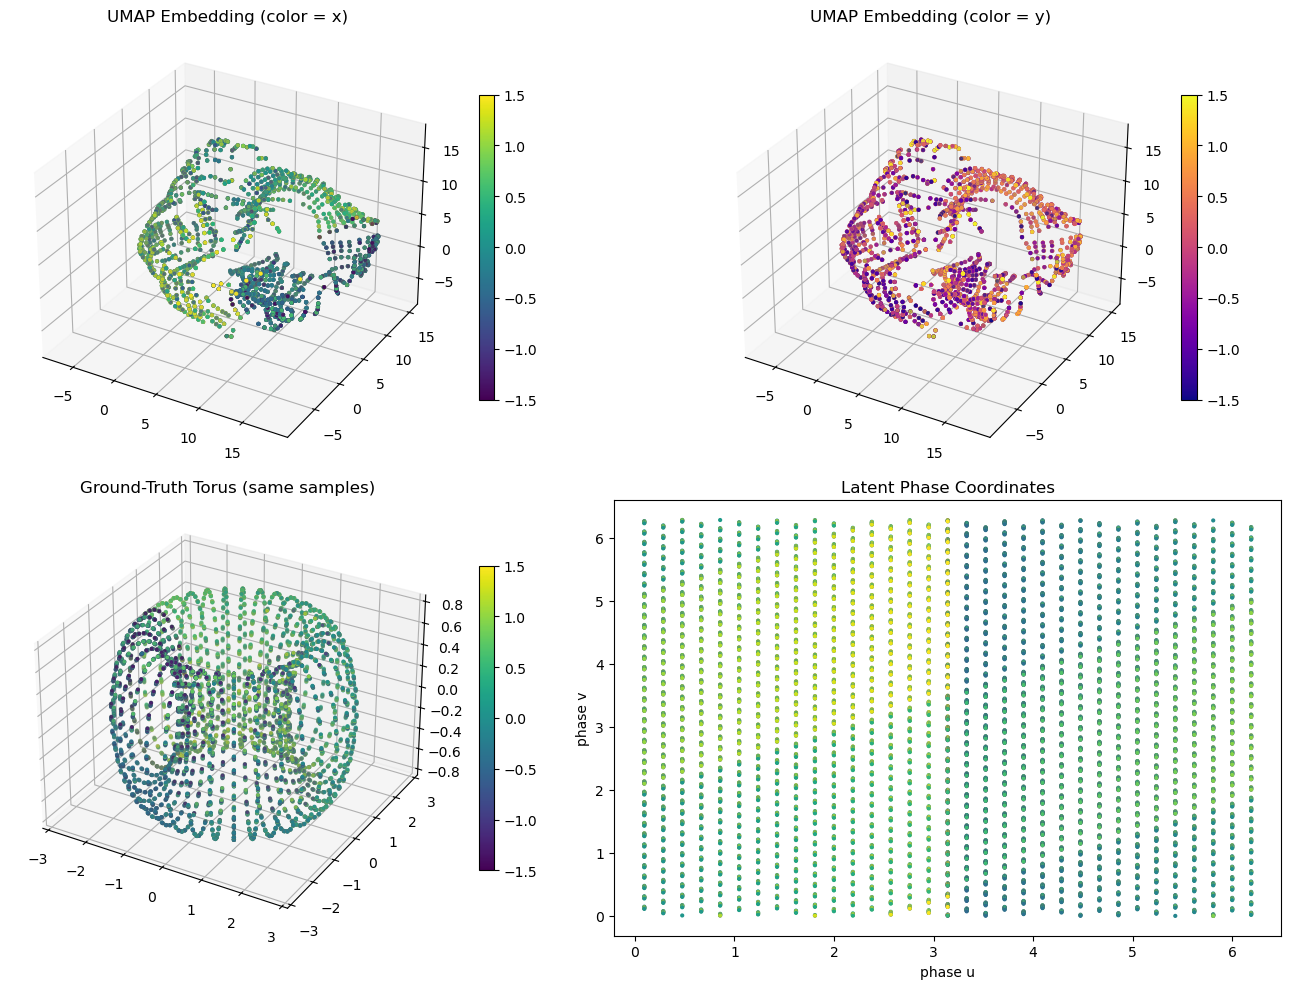

In [29]:
# Compare learned manifold vs known torus
fig = plt.figure(figsize=(14, 10))

ax1 = fig.add_subplot(221, projection="3d")
p1 = ax1.scatter(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], c=pos_sub[:, 0], s=4, cmap="viridis")
ax1.set_title("UMAP Embedding (color = x)")
fig.colorbar(p1, ax=ax1, shrink=0.7)

ax2 = fig.add_subplot(222, projection="3d")
p2 = ax2.scatter(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], c=pos_sub[:, 1], s=4, cmap="plasma")
ax2.set_title("UMAP Embedding (color = y)")
fig.colorbar(p2, ax=ax2, shrink=0.7)

ax3 = fig.add_subplot(223, projection="3d")
p3 = ax3.scatter(torus_sub[:, 0], torus_sub[:, 1], torus_sub[:, 2], c=pos_sub[:, 0], s=4, cmap="viridis")
ax3.set_title("Ground-Truth Torus (same samples)")
fig.colorbar(p3, ax=ax3, shrink=0.7)

ax4 = fig.add_subplot(224)
ax4.scatter(u_sub, v_sub, c=pos_sub[:, 0], s=4, cmap="viridis")
ax4.set_title("Latent Phase Coordinates")
ax4.set_xlabel("phase u")
ax4.set_ylabel("phase v")

plt.tight_layout()
plt.show()


If this synthetic baseline shows a clean torus-like structure under `PCA -> UMAP`, we can then plug in TPC population states using the same reducer.